In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import seaborn as sns
from imblearn.over_sampling import SMOTE
import pickle

In [2]:
sns.set(style = "white")
sns.set(style = "whitegrid", color_codes = True)

In [3]:
data = pd.read_csv('info.csv')

# Exploratory Data Analysis

In [4]:
data.describe()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,9.496162,0.832275,43.093517,0.018027,1362.272058,0.555838,0.160226,287.759306,15.806419,92.901418,258.163080,2.763841,40.197828,0.580323,816.775387,0.116985
std,10.618762,79.274312,0.608230,197.839921,0.133049,3044.765829,0.496878,0.366820,452.334507,8.322476,281.138685,257.527812,3.098021,100.128746,2.303441,385.649274,0.321406
min,18.000000,0.000000,0.000000,1.000000,0.000000,-8019.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000,0.000000
25%,33.000000,1.000000,0.000000,2.000000,0.000000,72.000000,0.000000,0.000000,0.000000,8.000000,5.000000,103.000000,1.000000,-1.000000,0.000000,999.000000,0.000000
50%,39.000000,3.000000,1.000000,2.000000,0.000000,448.000000,1.000000,0.000000,0.000000,16.000000,6.000000,180.000000,2.000000,-1.000000,0.000000,999.000000,0.000000
75%,48.000000,5.000000,1.000000,3.000000,0.000000,1428.000000,1.000000,0.000000,999.000000,21.000000,8.000000,319.000000,3.000000,-1.000000,0.000000,999.000000,0.000000
max,95.000000,999.000000,2.000000,999.000000,1.000000,102127.000000,1.000000,1.000000,999.000000,31.000000,999.000000,4918.000000,63.000000,871.000000,275.000000,999.000000,1.000000


In [5]:
data.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [6]:
data['default'].value_counts()

0    44396
1      815
Name: default, dtype: int64

# Visualization

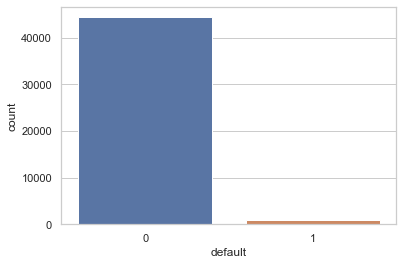

In [7]:
sns.countplot(x = 'default', data = data)
plt.show()

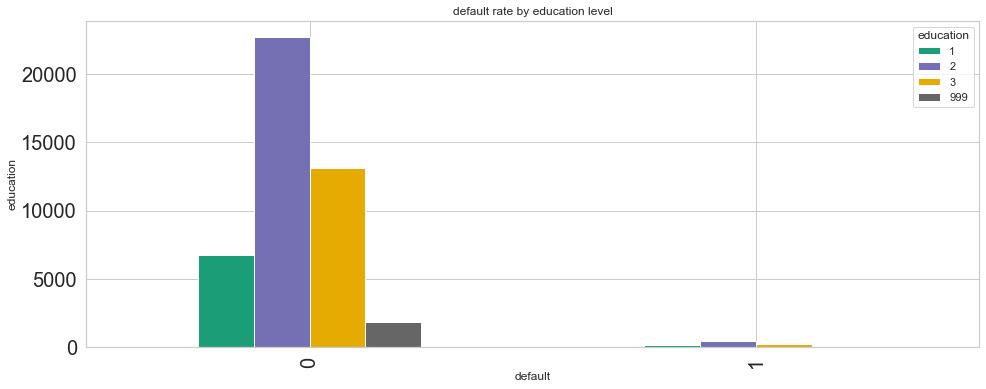

In [8]:
%matplotlib inline 
pd.crosstab(data.default, data.education).plot(kind = 'bar', figsize = (16, 6), colormap = 'Dark2', fontsize = 20)
plt.title('default rate by education level')
plt.xlabel('default')
plt.ylabel('education')
plt.show()

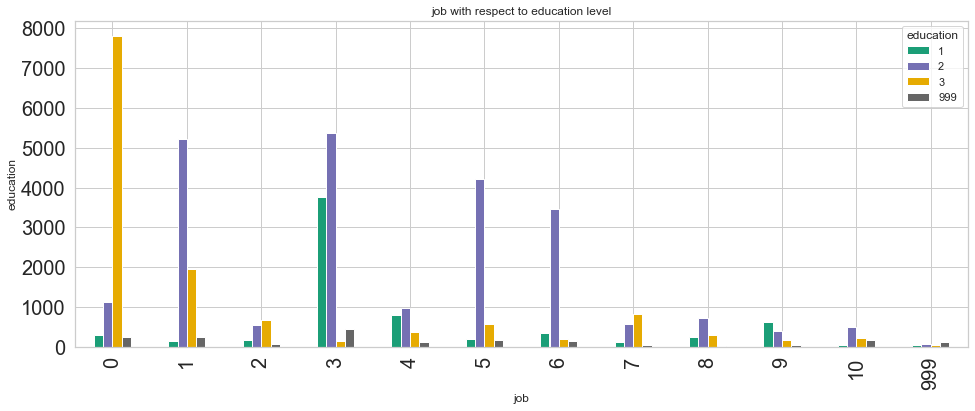

In [9]:
%matplotlib inline 
pd.crosstab(data.job, data.education).plot(kind = 'bar', figsize = (16, 6), colormap = 'Dark2', fontsize = 20)
plt.title('job with respect to education level')
plt.xlabel('job')
plt.ylabel('education')
plt.show()

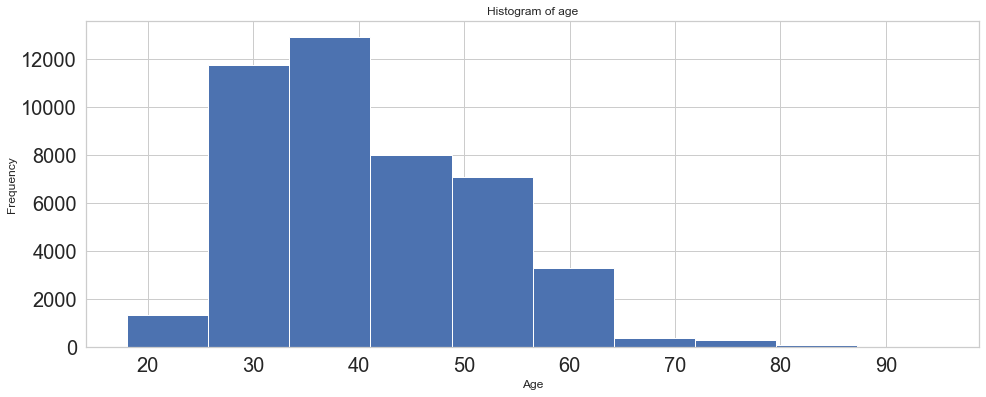

In [10]:
data.age.hist(figsize = (16, 6), xlabelsize = 20, ylabelsize = 20)
plt.title('Histogram of age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  int64
 2   marital    45211 non-null  int64
 3   education  45211 non-null  int64
 4   default    45211 non-null  int64
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  int64
 7   loan       45211 non-null  int64
 8   contact    45211 non-null  int64
 9   day        45211 non-null  int64
 10  month      45211 non-null  int64
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  int64
 16  y          45211 non-null  int64
dtypes: int64(17)
memory usage: 5.9 MB


In [12]:
cat_vars = ['default', 'y', 'balance', 'housing']
for var in cat_vars:
    cat_list = pd.get_dummies(data[var], prefix = var)
    data1 = data.join(cat_list)
    data = data1
data_vars = data.columns.values.tolist()

In [13]:
print(data_vars)

['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'default_0', 'default_1', 'y_0', 'y_1', 'balance_-8019', 'balance_-6847', 'balance_-4057', 'balance_-3372', 'balance_-3313', 'balance_-3058', 'balance_-2827', 'balance_-2712', 'balance_-2604', 'balance_-2282', 'balance_-2122', 'balance_-2093', 'balance_-2082', 'balance_-2049', 'balance_-1980', 'balance_-1968', 'balance_-1965', 'balance_-1944', 'balance_-1941', 'balance_-1884', 'balance_-1882', 'balance_-1854', 'balance_-1818', 'balance_-1781', 'balance_-1779', 'balance_-1746', 'balance_-1737', 'balance_-1730', 'balance_-1725', 'balance_-1701', 'balance_-1680', 'balance_-1668', 'balance_-1664', 'balance_-1661', 'balance_-1655', 'balance_-1636', 'balance_-1629', 'balance_-1621', 'balance_-1613', 'balance_-1601', 'balance_-1598', 'balance_-1586', 'balance_-1547', 'balance_-1545', 'balance_-1531', 'balance_-1500', 'balance_

In [14]:
data.loc[:, 'default':'education'].head()

""
0
1
2
3
4


In [15]:
columns_to_keep = [i for i in data_vars if i not in cat_vars]
print(columns_to_keep)

['age', 'job', 'marital', 'education', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'default_0', 'default_1', 'y_0', 'y_1', 'balance_-8019', 'balance_-6847', 'balance_-4057', 'balance_-3372', 'balance_-3313', 'balance_-3058', 'balance_-2827', 'balance_-2712', 'balance_-2604', 'balance_-2282', 'balance_-2122', 'balance_-2093', 'balance_-2082', 'balance_-2049', 'balance_-1980', 'balance_-1968', 'balance_-1965', 'balance_-1944', 'balance_-1941', 'balance_-1884', 'balance_-1882', 'balance_-1854', 'balance_-1818', 'balance_-1781', 'balance_-1779', 'balance_-1746', 'balance_-1737', 'balance_-1730', 'balance_-1725', 'balance_-1701', 'balance_-1680', 'balance_-1668', 'balance_-1664', 'balance_-1661', 'balance_-1655', 'balance_-1636', 'balance_-1629', 'balance_-1621', 'balance_-1613', 'balance_-1601', 'balance_-1598', 'balance_-1586', 'balance_-1547', 'balance_-1545', 'balance_-1531', 'balance_-1500', 'balance_-1493', 'balance_-1490', 'balance_-148

In [16]:
data['y'].value_counts()

0    39922
1     5289
Name: y, dtype: int64

In [17]:
data = data[columns_to_keep]
data.columns

Index(['age', 'job', 'marital', 'education', 'loan', 'contact', 'day', 'month',
       'duration', 'campaign',
       ...
       'balance_59649', 'balance_64343', 'balance_66653', 'balance_66721',
       'balance_71188', 'balance_81204', 'balance_98417', 'balance_102127',
       'housing_0', 'housing_1'],
      dtype='object', length=7187)

# over sampling using SMOTE

In [18]:
X = data.loc[:, data.columns != 'loan']
y =  data.loc[:, data.columns == 'loan']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

In [20]:
over_sampling = SMOTE(random_state = 0)

In [21]:
columns = X_train.columns

In [22]:
over_sample_X, over_sample_y = over_sampling.fit_resample(X_train, y_train) 

In [23]:
len(over_sample_X)

53122

In [24]:
len(over_sample_y)

53122

In [25]:
len(over_sample_y[over_sample_y['loan'] == 0])

26561

In [26]:
len(over_sample_y[over_sample_y['loan'] == 1])

26561